# 전처리 & 머신러닝 통합 개인과제

## Part 3. 구매 가능 고객 예측

### 실무 시나리오

전자상거래 기업의 CRM팀은 모든 고객에게 동일한 프로모션을 제공하면서 마케팅 비용이 증가하고 있습니다.  
데이터 분석팀은 Part 1에서 정비한 고객 데이터와 Part 2에서 확인한 구매 특성을 활용하여 **구매 가능성이 높은 고객을 선별하는 예측 모델**을 개발하려고 합니다.

수강생은 데이터 분석 담당자로서 다음 업무를 수행합니다.

1. 구매 여부 예측 문제와 모델링 데이터를 정의합니다.
2. 기본 분류 모델을 개발하고 성능을 평가합니다.
3. 모델을 조정한 뒤 기본 모델과 비교하고 과적합 여부를 진단합니다.

> 문제 1~3은 필수 문제입니다.  
> 문제 4는 추가 모델 검토를 위한 심화 문제이며 선택적으로 수행합니다.

## 과제 목표

- 구매 여부 예측 문제를 분류 문제로 정의하고 적절한 입력 변수와 타깃 변수를 구성할 수 있습니다.
- 수치형·범주형 데이터에 필요한 전처리를 적용하여 기본 분류 모델을 학습할 수 있습니다.
- Accuracy, Precision, Recall, F1-score와 혼동행렬을 활용하여 모델 성능을 평가할 수 있습니다.
- 기본 모델과 개선 모델의 학습·검증 성능을 비교하여 성능 개선과 과적합 여부를 판단할 수 있습니다.

## 사용 환경 및 데이터

- Python 3.X
- pandas, numpy
- `전자상거래_고객구매_전처리완료.csv`

# 문제 1. 예측 문제와 학습 데이터 구성

## 업무 상황

CRM팀은 고객의 현재 정보를 바탕으로 구매 가능성이 높은 고객을 구분하려고 합니다.  
모델 개발 전에 예측 대상과 입력 변수를 정하고, 실제 예측 시점에 사용할 수 없는 정보가 포함되지 않았는지 확인해야 합니다.

## 필수 요구사항

1. 전처리 완료 데이터를 불러오고 데이터 크기와 주요 컬럼을 확인하세요.
2. `PurchaseStatus`의 클래스별 개수와 비율을 확인하세요.
3. 해당 예측 과제가 분류 문제인지 회귀 문제인지 작성하세요.
4. 타깃 변수 `y`와 입력 변수 `X`를 구성하세요.
5. 고객 식별 정보와 예측에 적절하지 않은 변수를 제외하세요.
6. 학습 데이터와 검증 데이터를 분리하세요.

### 힌트

- 고객을 직접 식별하는 컬럼은 일반적인 구매 행동 패턴 학습에 적절하지 않을 수 있습니다.
- 날짜는 그대로 사용하기보다 기준일과의 차이를 수치로 변환할 수 있습니다.
- 클래스 비율을 유지하면서 데이터를 분리하는 방법을 생각해보세요.

In [1]:
import pandas as pd
import numpy as np

DATA_PATH = "전자상거래_고객구매_전처리완료.csv"

# TODO: 데이터를 불러오고 기본 구조를 확인하세요.
df = pd.read_csv(DATA_PATH)

# 기본 구조
print("데이터크기:", df.shape) 
print("주요컬럼:", df.columns) 

counts = df['PurchaseStatus'].value_counts()
percentages = df['PurchaseStatus'].value_counts(normalize=True) * 100


status_summary = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentages
})

print(status_summary)   

데이터크기: (1500, 17)
주요컬럼: Index(['CustomerID', 'Gender', 'Age', 'Region', 'MembershipLevel',
       'VisitCount', 'AveragePurchaseAmount', 'TotalPurchaseAmount',
       'SatisfactionScore', 'LastPurchaseDate', 'CouponUsed',
       'PreferredCategory', 'SignupDate', 'Email', 'PurchaseStatus',
       'AgeGroup', 'PurchaseGrade'],
      dtype='str')
                Count  Percentage (%)
PurchaseStatus                       
0                 767       51.133333
1                 733       48.866667


In [ ]:
# TODO: 날짜형 변수를 활용하여 필요한 파생변수를 생성하세요.
# TODO: 입력 변수 X와 타깃 변수 y를 구성하세요.
# TODO: 식별 정보 및 예측 시점에 부적절한 변수를 제외하세요.

# 사용할 df
model_df_log_clipped = pd.read_pickle("model_df_log_clipped.pkl")
df = model_df_log_clipped

# 파생변수 생성
# 문자열 칼럼을 날짜(datetime) 타입으로 변환
df['SignupDate'] = pd.to_datetime(df['SignupDate'])
df['LastPurchaseDate'] = pd.to_datetime(df['LastPurchaseDate'])


# 기준일 설정 (가장 최근 가입일시)
ref_date = df['SignupDate'].max()

# 기준일 대비 가입 후 경과 일수 (가입 기간) 
df['Days_Since_Signup'] = (ref_date - df['SignupDate']).dt.days

# 기준일 대비 마지막 구매 후 경과 일수 (최근성, NaT는 -1로 대체)
df['Days_Since_LastPurchase'] = (ref_date - df['LastPurchaseDate']).dt.days.fillna(-1)

# 가입 시점부터 마지막 구매까지의 기간 (활동성, NaT는 -1로 대체)
df['Days_Signup_To_LastPurchase'] = (df['LastPurchaseDate'] - df['SignupDate']).dt.days.fillna(-1)

# 모델 정의
model_df = df.copy()

# X에서 제외할 칼럼 정의
# 타겟 변수: PurchaseStatus
# 고유 식별자변수

feature_cols = [
    "Log_Total_Purchase_Amount_Clipped",
    "Visit_Count_Clipped",
    "MembershipLevel",
    "Days_Since_LastPurchase"
]

X = model_df[feature_cols]
y = model_df['PurchaseStatus']

In [3]:
from sklearn.model_selection import train_test_split

# TODO: 학습 데이터와 검증 데이터를 분리하세요.
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # 타깃 변수 클래스 비율 유지
)

### 문제 1 결과 작성

- 문제 유형: PurchaseStatus(구매상태) 여부를 예측하는 이진 분류 문제

- 타깃 변수의 의미: 고객의 향후 구매 상태를 예측하고자 하는 목적 변수 

- 사용한 주요 입력 변수: "Log_Total_Purchase_Amount_Clipped","Visit_Count_Clipped", "MembershipLevel", "Days_Since_LastPurchase"

- 제외한 변수: CustomerID(고유 식별자 변수), PurchaseStatus(타겟변수), SignupDate, LastPurchaseDate (파생변수를 생성했으므로  제거)

- 학습·검증 데이터 크기: 전체 데이터의 80%를 학습(Train) 데이터로, 20%(test_size=0.2)를 검증(Validation) 데이터로 분리

- 클래스 비율을 유지하여 분리한 이유: 
특정 클래스가 한쪽 데이터에 편중되는 것을 방지하고, 검증 데이터에서도 실제 데이터의 클래스 분포를 반영하여 모델의 성능을 보다 공정하게 평가할 수 있도록 하기 위해서



# 문제 2. 기본 구매예측 모델 개발 및 평가

## 업무 상황

CRM팀은 먼저 복잡하지 않고 결과를 설명하기 쉬운 기본 모델을 구축하려고 합니다.  
분석 담당자는 수치형·범주형 변수에 필요한 전처리를 적용하고, 구매 여부를 예측하는 기본 분류 모델을 학습해야 합니다.

## 필수 요구사항

1. 수치형 변수와 범주형 변수를 구분하세요.
2. 각 변수 유형에 필요한 결측치 처리와 변환을 적용하세요.
3. 전처리 과정과 분류 모델이 연결되도록 기본 모델을 구성하세요.
4. 검증 데이터에 대한 예측 결과를 생성하세요.
5. Accuracy, Precision, Recall, F1-score를 계산하세요.
6. 혼동행렬을 확인하세요.
7. 사용한 기본 분류 모델을 제시하고, 해당 모델이 구매 여부 예측 문제에 적합한 이유를 작성하세요.
8. CRM 업무 목적을 고려하여 중요하게 볼 평가 지표를 하나 선택하고 이유를 작성하세요.

### 힌트

- 수치형 변수에는 대표값 대체와 스케일링을 적용할 수 있습니다.
- 범주형 변수에는 대표값 대체와 One-Hot Encoding을 적용할 수 있습니다.
- 기본 모델로 Logistic Regression을 사용할 수 있습니다.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# 수치형·범주형 변수 구분
numeric_features = [
    'Log_Total_Purchase_Amount_Clipped',
    'Visit_Count_Clipped',
    'Days_Since_LastPurchase'
]

categorical_features = [
    'MembershipLevel'
]

# 수치형 전처리
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


# 범주형 전처리
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# 전처리기 구성
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Baseline_model
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])


=== Base Model Evaluation Metrics ===
Accuracy: 0.7133
Precision: 0.7047
Recall: 0.7143
F1-Score: 0.7095

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.72      0.71      0.72       153
           1       0.70      0.71      0.71       147

    accuracy                           0.71       300
   macro avg       0.71      0.71      0.71       300
weighted avg       0.71      0.71      0.71       300



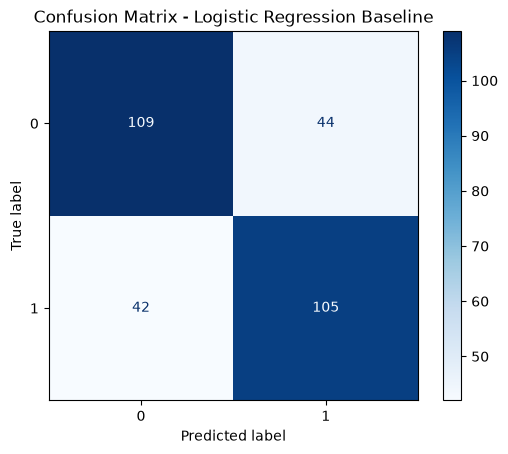

In [5]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# TODO: 기본 모델을 학습하고 검증 데이터를 예측하세요.
# 모델 학습
baseline_model.fit(X_train, y_train)
# 검증 데이터 예측
y_train_pred = baseline_model.predict(X_train)
y_valid_pred = baseline_model.predict(X_valid)

# TODO: 주요 평가 지표를 계산하고 혼동행렬을 확인하세요.

acc = accuracy_score(y_valid, y_valid_pred)
prec = precision_score(y_valid, y_valid_pred, average='binary')
rec = recall_score(y_valid, y_valid_pred, average='binary')
f1 = f1_score(y_valid, y_valid_pred, average='binary')

baseline_metrics = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1-Score': f1
}

print("=== Base Model Evaluation Metrics ===")
for metric, score in baseline_metrics.items():
    print(f"{metric}: {score:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_valid, y_valid_pred))

# 혼동행렬(Confusion Matrix) 시각화
ConfusionMatrixDisplay.from_estimator(
    baseline_model, 
    X_valid, 
    y_valid, 
    cmap='Blues'
)
plt.title("Confusion Matrix - Logistic Regression Baseline")
plt.show()


### 문제 2 결과 작성

- 기본 모델: Logistic Regression (로지스틱 회귀)

- 기본 모델 선택 이유: 

classification(분류)가 목적이었고 회귀 계수(Coefficient)를 통해 각 변수가 구매 예측에 미치는 영향력을 직관적으로 해석할 수 있기 때문에.

- 수치형 변수 전처리: SimpleImputer(중앙값 대체) + StandardScaler(표준화 스케일링)

- 범주형 변수 전처리: SimpleImputer(최빈값 대체) + OneHotEncoder(원-핫 인코딩)

- Accuracy: 0.7133

- Precision: 0.7047

- Recall: 0.7143

- F1-score: 0.7095

- 중요하게 선택한 평가 지표와 이유: F1-score

이유:
Precision과 Recall을 동시에 고려할 수 있기 때문이다. 구매 고객을 놓치는 것(Recall)과 구매한다고 예측한 고객 중 실제 구매자를 잘못 분류하는 것(Precision)을 모두 고려할 필요가 있으므로, 두 지표의 균형을 평가할 수 있는 F1-score를 주요 평가 지표로 선택함. 다만 클래스 비율이 비교적 균형적이므로 Accuracy도 함께 참고하면 좋음.


- 혼동행렬에서 확인한 주요 오분류:

FP(False Positive)는 44건, FN(False Negative)은 42건으로 두 오분류 유형이 비슷한 수준으로 발생함. 특정 한쪽의 오분류가 크게 집중되지 않았으며, 실제 구매자를 놓치는 경우와 비구매자를 구매자로 잘못 예측하는 경우가 비교적 균형적으로 나타난다고 생각함.

# 문제 3. 모델 개선 및 최종 모델 선택

## 업무 상황

기본 모델의 결과를 확인한 CRM팀은 모델을 실제 캠페인 대상 선정에 활용할 수 있는지 검토하려고 합니다.  
분석 담당자는 모델 설정을 조정하여 개선 모델을 만들고, 기본 모델과 성능을 비교한 뒤 과적합 여부를 확인해야 합니다.

## 필수 요구사항

1. 기본 모델의 학습 성능과 검증 성능을 계산하세요.
2. 규제 강도 또는 클래스 가중치 등의 설정을 조정하여 개선 모델을 개발하세요.
3. 개선 모델의 학습 성능과 검증 성능을 계산하세요.
4. 기본 모델과 개선 모델의 성능 비교표를 작성하세요.
5. 학습 F1-score와 검증 F1-score의 차이를 확인하여 과적합 여부를 진단하세요.
6. 검증 성능과 과적합 정도를 함께 고려하여 최종 모델을 선택하세요.
7. 학습·검증 성능 차이가 발생한 원인을 설명하고, 적용한 규제 또는 하이퍼파라미터 조정이 성능과 과적합에 어떤 영향을 주었는지 작성하세요.
8. 개선 모델의 성능이 높아지지 않았다면 그 결과도 그대로 비교하고 설명하세요.
9. 최종 모델의 성능상 한계 또는 실제 업무 적용 시 주의할 점을 한 가지 이상 작성하세요.

### 힌트

- Logistic Regression의 규제 강도 또는 `class_weight`를 조정할 수 있습니다.
- 학습 성능이 높더라도 검증 성능과의 차이가 크면 과적합 가능성이 있습니다.
- 개선 모델이 반드시 기본 모델보다 좋아야 하는 것은 아닙니다.

In [6]:
# TODO: 조정한 설정을 적용하여 개선 모델을 구성하고 학습하세요.
improved_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        C=0.1, # 규제 강도를 높여 일반화 성능 유도
        class_weight='balanced', # 클래스 불균형 완화 및 Recall/F1 개선
        random_state=42, 
        max_iter=1000
    ))
])

# 개선 모델 학습
improved_model.fit(X_train, y_train)

# 검증 데이터 예측
y_train_pred_imp = improved_model.predict(X_train)
y_val_pred_imp = improved_model.predict(X_valid)

In [7]:
# TODO: 기본 모델과 개선 모델의 학습·검증 성능을 비교하세요.
# 권장 지표: Accuracy, Precision, Recall, F1-score, Train F1 - Validation F1

def get_performance_metrics(y_true_train, y_pred_train, y_true_valid, y_pred_valid):
    # Train 지표
    train_acc = accuracy_score(y_true_train, y_pred_train)
    train_prec = precision_score(y_true_train, y_pred_train, average='binary')
    train_rec = recall_score(y_true_train, y_pred_train, average='binary')
    train_f1 = f1_score(y_true_train, y_pred_train, average='binary')
    
    # Valid 지표
    valid_acc = accuracy_score(y_true_valid, y_pred_valid)
    valid_prec = precision_score(y_true_valid, y_pred_valid, average='binary')
    valid_rec = recall_score(y_true_valid, y_pred_valid, average='binary')
    valid_f1 = f1_score(y_true_valid, y_pred_valid, average='binary')
    
    # F1 차이 (과적합 진단)
    f1_diff = train_f1 - valid_f1
    
    return {
        'Train Accuracy': train_acc,
        'Valid Accuracy': valid_acc,
        'Train Precision': train_prec,
        'Valid Precision': valid_prec,
        'Train Recall': train_rec,
        'Valid Recall': valid_rec,
        'Train F1-score': train_f1,
        'Valid F1-score': valid_f1,
        'Train-Valid F1 Diff': f1_diff
    }

base_metrics = get_performance_metrics(y_train, y_train_pred, y_valid, y_valid_pred)
imp_metrics = get_performance_metrics(y_train, y_train_pred_imp, y_valid, y_val_pred_imp)

comparison_df = pd.DataFrame([base_metrics, imp_metrics], index=['Base Model', 'Improved Model']).T

print("=== 기본 모델 vs 개선 모델 성능 비교 ===")
print(comparison_df.round(4))

=== 기본 모델 vs 개선 모델 성능 비교 ===
                     Base Model  Improved Model
Train Accuracy           0.6900          0.6883
Valid Accuracy           0.7133          0.7133
Train Precision          0.6918          0.6779
Valid Precision          0.7047          0.7020
Train Recall             0.6587          0.6894
Valid Recall             0.7143          0.7211
Train F1-score           0.6748          0.6836
Valid F1-score           0.7095          0.7114
Train-Valid F1 Diff     -0.0346         -0.0278


### 문제 3 결과 작성

- 조정한 모델 설정: Logistic Regression의 규제 강도 및 클래스 가중치 조정 (C=0.1, class_weight='balanced')

- 기본 모델 검증 F1-score: 0.7095

- 개선 모델 검증 F1-score: 0.7114

- 기본 모델 학습·검증 차이: 0.0346 (Train F1 0.6748 - Valid F1 0.7095)

- 개선 모델 학습·검증 차이: 0.0278 (Train F1 0.6836 - Valid F1 0.7114)

- 과적합 진단:

두 모델 모두 학습 F1-score보다 검증 F1-score가 높게 나타났으며, 학습과 검증 간 F1-score 차이도 크지 않아 심각한 과적합 문제는 확인되지 않았다. 특히 개선 모델은 학습·검증 간 차이가 0.0346에서 0.0278로 감소하였다.

- 학습·검증 성능 차이의 원인:

학습 데이터와 검증 데이터의 표본 구성 차이로 인해 성능에 차이가 발생할 수 있다. 이번 결과에서는 검증 F1-score가 학습 F1-score보다 높게 나타났으므로 과적합으로 인한 성능 저하보다는 데이터 분할에 따른 차이로 판단된다.

- 규제 또는 하이퍼파라미터 조정의 효과:

규제 강도 조정 및 클래스 가중치 적용을 통해 검증 Recall(0.7143 → 0.7211)과 F1-score(0.7095 → 0.7114)가 상승하였다. 또한 학습·검증 간 F1-score 차이도 0.0346에서 0.0278로 감소하였다.

- 최종 선택 모델: 개선 모델 (Improved Model)

- 최종 모델 선택 이유:

1. 검증 F1-score가 0.7095에서 0.7114로 향상되었다.
2. 검증 Recall이 0.7143에서 0.7211로 향상되어 실제 구매 고객을 더 많이 찾아낼 수 있다.
3. 학습·검증 간 F1-score 차이가 감소하여 두 데이터에서의 성능 차이가 더 작게 나타났다.

- 모델 활용 방안:

CRM 마케팅 타깃팅 시 구매 가능성이 높은 고객군을 선별하여 프로모션 쿠폰 발송 및 맞춤형 캠페인 대상으로 활용할 수 있다.

- 최종 모델의 한계 또는 업무 적용 시 주의점:

확률 임계값(Threshold) 조정 필요: 기본 예측 임계값 0.5 대신 마케팅 예산이나 캠페인 목표에 맞춰 Precision과 Recall의 균형을 고려하여 적절한 임계값을 설정할 필요가 있다.

선형 모델의 한계: Logistic Regression은 변수 간 복잡한 비선형 관계와 상호작용을 충분히 반영하기 어렵기 때문에, 향후 성능 향상을 위해 Random Forest나 LightGBM 등의 트리 기반 모델과 비교할 필요가 있다.


# (심화)문제 4. 모델 운영을 위한 추가 검토

## 업무 상황

CRM팀은 기본 모델과 개선 모델의 비교 결과를 확인한 뒤, 실제 캠페인에 모델을 적용하기 전에 모델 성능을 추가로 검증하고 운영 기준을 검토하려고 합니다.

## 요구사항

### 4-1. 추가 모델 비교

1. 기본 모델과 다른 특성을 가진 분류 모델을 한 개 추가로 학습하세요.
2. 동일한 검증 데이터를 사용하여 Accuracy, Precision, Recall, F1-score를 계산하세요.
3. 기존 모델과 추가 모델의 성능 및 해석 가능성을 비교하세요.

### 4-2. 교차검증을 활용한 하이퍼파라미터 탐색

1. 교차검증 또는 `GridSearchCV`를 활용하여 여러 하이퍼파라미터 조합을 비교하세요.
2. 최적 하이퍼파라미터와 교차검증 성능을 확인하세요.
3. 최적 모델의 검증 성능을 기본 모델 및 개선 모델과 비교하세요.

### 4-3. 예측 기준값과 오분류 비용 검토

1. 예측 확률의 기준값을 변경하여 Precision과 Recall의 변화를 확인하세요.
2. CRM 캠페인에서 False Positive와 False Negative가 각각 어떤 비용 또는 기회 손실을 발생시키는지 설명하세요.
3. 업무 목적에 적합한 예측 기준값을 제안하세요.

### 힌트

- 추가 모델로 Decision Tree 등을 사용할 수 있습니다.
- 예측 기준값을 낮추면 일반적으로 Recall이 높아지고, 높이면 Precision이 높아질 수 있습니다.
- 심화 문제는 선택 사항이며 수행하지 않아도 필수 문제 제출에는 문제가 없습니다.


In [8]:
# 심화 문제 4-1
# TODO: 기본 모델과 다른 분류 모델을 추가로 학습하고 성능을 비교하세요.
additional_model = None

In [9]:
# 심화 문제 4-2
# TODO: 교차검증 또는 GridSearchCV로 하이퍼파라미터를 탐색하세요.
search_result = None

In [10]:
# 심화 문제 4-3
# TODO: 예측 기준값별 Precision, Recall, F1-score를 비교하세요.
threshold_result = None


## 심화 문제 결과 작성

### 4-1. 추가 모델 비교

- 추가한 모델:
- 추가 모델을 선택한 이유:
- 기존 모델과의 성능 비교:
- 해석 가능성 및 복잡도 비교:

### 4-2. 하이퍼파라미터 탐색

- 탐색한 하이퍼파라미터:
- 최적 하이퍼파라미터:
- 교차검증 성능:
- 검증 데이터 성능:
- 기존 모델과의 비교 결과:

### 4-3. 예측 기준값과 오분류 비용

- 비교한 예측 기준값:
- 기준값별 Precision과 Recall 변화:
- False Positive의 업무 비용:
- False Negative의 업무 비용:
- 제안하는 최종 기준값과 이유:



# 제출 전 체크리스트

## 필수 체크리스트

- [ ] 구매 여부 예측 문제를 분류 문제로 정의했습니다.
- [ ] 입력 변수와 타깃 변수를 구성했습니다.
- [ ] 식별 정보와 예측에 부적절한 변수를 제외했습니다.
- [ ] 학습 데이터와 검증 데이터를 분리했습니다.
- [ ] 수치형·범주형 전처리를 적용했습니다.
- [ ] 기본 분류 모델을 학습했습니다.
- [ ] 사용한 기본 모델이 구매 여부 예측에 적합한 이유를 작성했습니다.
- [ ] Accuracy, Precision, Recall, F1-score와 혼동행렬을 확인했습니다.
- [ ] 모델 설정을 조정하여 개선 모델을 만들었습니다.
- [ ] 기본 모델과 개선 모델의 성능을 비교했습니다.
- [ ] 학습·검증 성능을 비교하여 과적합 여부를 진단했습니다.
- [ ] 학습·검증 성능 차이의 원인과 모델 조정 효과를 설명했습니다.
- [ ] 최종 모델을 선택하고 이유를 작성했습니다.
- [ ] 최종 모델의 한계 또는 실제 업무 적용 시 주의점을 작성했습니다.

## 심화 체크리스트

- [ ] 다른 분류 모델을 추가로 학습하고 비교했습니다.
- [ ] 교차검증 또는 GridSearchCV를 적용했습니다.
- [ ] 예측 기준값에 따른 Precision과 Recall 변화를 확인했습니다.
- [ ] False Positive와 False Negative의 업무 비용을 설명했습니다.
- [ ] 업무 목적에 적합한 예측 기준값을 제안했습니다.
